<h1>Train — ResNet-18 (baseline)</h1>

Trains and evaluates the ResNet-18 baseline classifier, then saves its results (`results_resnet18.pkl`) and weights (`{COMPONENT}_resnet18_cnn.pt`) to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1945 | Val: 472 | Test: 90


## Define the model (Transfer Learning with ResNet-18)

In [2]:
model_resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

num_ftrs = model_resnet18.fc.in_features
model_resnet18.fc = nn.Linear(num_ftrs, num_classes)  # no hidden layers — this one predates the tuning sweep

model_resnet18 = model_resnet18.to(device)

# ---------------------------------------------------------
# Loss and optimizer, with class weights for the imbalanced classes
# ---------------------------------------------------------
class_weights = make_class_weights(train_ds)
print("Applying class weights to loss function:")
for name, w in zip(class_names, class_weights.cpu().numpy()):
    print(f"  {name:<15s}: {w:.3f}")

criterion_resnet18 = nn.CrossEntropyLoss(weight=class_weights)
optimizer_resnet18 = optim.Adam(model_resnet18.parameters(), lr=5e-4, weight_decay=WEIGHT_DECAY)

# mode='min' because we want to minimize loss; factor=0.5 halves the LR when
# triggered; patience=3 waits 3 epochs with no improvement before reducing it
scheduler_resnet18 = ReduceLROnPlateau(optimizer_resnet18, mode='min', factor=0.5, patience=3)

Applying class weights to loss function:
  Dysfunctional  : 1.478
  Empty          : 1.667
  Functional     : 0.436
  Scum           : 0.420


## Train, then plot training curves

[ResNet-18] Epoch   1/100 | LR: 5.00e-04 | train loss 0.7828 acc 0.670 | val loss 0.7004 acc 0.718 *


[ResNet-18] Epoch   2/100 | LR: 5.00e-04 | train loss 0.4137 acc 0.814 | val loss 0.5953 acc 0.765 *


[ResNet-18] Epoch   3/100 | LR: 5.00e-04 | train loss 0.3256 acc 0.853 | val loss 0.6166 acc 0.790


[ResNet-18] Epoch   4/100 | LR: 5.00e-04 | train loss 0.2533 acc 0.885 | val loss 0.6032 acc 0.790


[ResNet-18] Epoch   5/100 | LR: 5.00e-04 | train loss 0.2730 acc 0.893 | val loss 0.7933 acc 0.691


...

[ResNet-18] Epoch  13/100 | LR: 1.25e-04 | train loss 0.0053 acc 0.999 | val loss 0.6942 acc 0.839


[ResNet-18] Epoch  14/100 | LR: 1.25e-04 | train loss 0.0032 acc 0.999 | val loss 0.7121 acc 0.837


[ResNet-18] Epoch  15/100 | LR: 6.25e-05 | train loss 0.0034 acc 0.999 | val loss 0.7000 acc 0.841


[ResNet-18] Epoch  16/100 | LR: 6.25e-05 | train loss 0.0025 acc 1.000 | val loss 0.7184 acc 0.843


[ResNet-18] Epoch  17/100 | LR: 6.25e-05 | train loss 0.0024 acc 1.000 | val loss 0.7008 acc 0.845

[ResNet-18] No val loss improvement for 10 epochs — stopping early at epoch 17.

[ResNet-18] Restored best checkpoint (val loss = 0.5240)


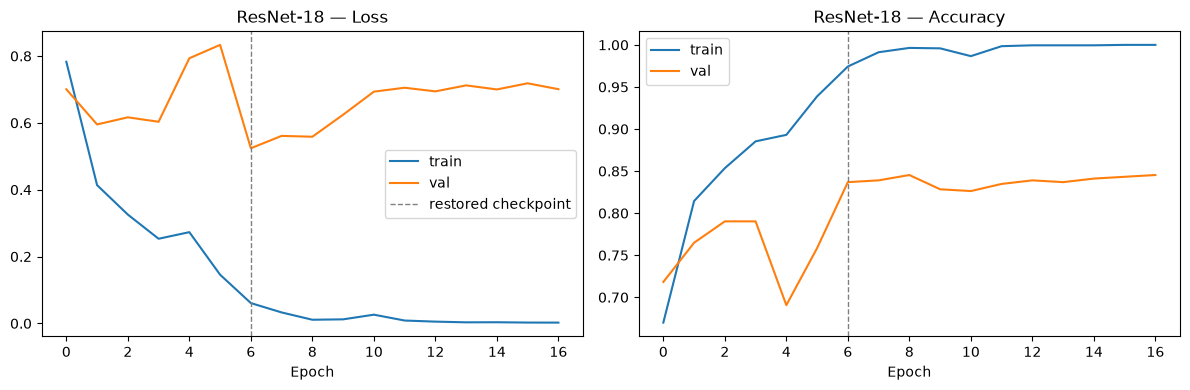

In [3]:
history_resnet18 = train_model(
    model_resnet18, train_loader, val_loader, optimizer_resnet18, scheduler_resnet18,
    criterion_resnet18, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-18",
)
plot_training_curves(history_resnet18, "ResNet-18")

## Evaluate on the test set

[ResNet-18] Test accuracy: 0.811


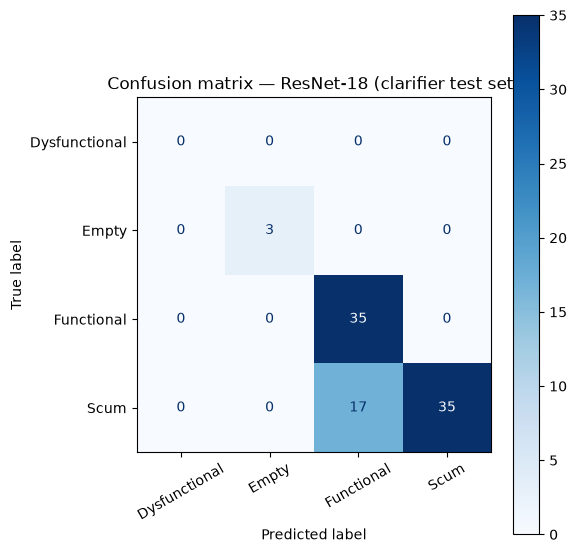

               precision    recall  f1-score   support

Dysfunctional      0.000     0.000     0.000         0
        Empty      1.000     1.000     1.000         3
   Functional      0.673     1.000     0.805        35
         Scum      1.000     0.673     0.805        52

     accuracy                          0.811        90
    macro avg      0.668     0.668     0.652        90
 weighted avg      0.873     0.811     0.811        90

  [warn] 'Dysfunctional' has 0 examples in this test set — AUC undefined, skipping.


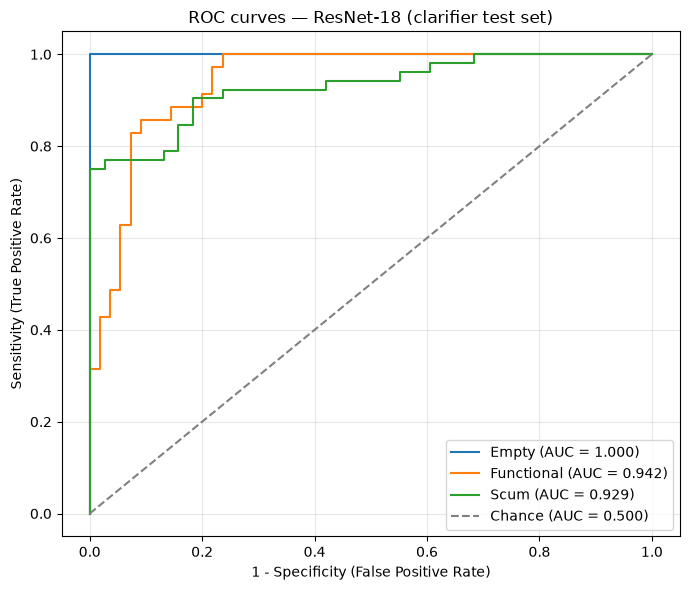

AUC (area under ROC curve) per class:
  Dysfunctional  : undefined (0 examples)
  Empty          : 1.000
  Functional     : 0.942
  Scum           : 0.929

Mean AUC (over 3/4 classes with test examples): 0.957


(np.float64(0.8111111111111111),
 {'Dysfunctional': nan,
  'Empty': 1.0,
  'Functional': 0.9418181818181819,
  'Scum': 0.9291497975708503})

In [4]:
evaluate_and_record(
    model_resnet18, test_loader, "ResNet-18", history_resnet18,
    img_size=IMG_TARGET_SIZE, hidden_layers=0, neurons=None,
)

## Save results + model weights to disk

This is the step the results notebook depends on — it pickles the metrics/history and saves the model state dict so nothing needs to be kept in memory or re-trained.

In [5]:
save_result("ResNet-18", "resnet18")

Saved results to ../results/results_clarifier_resnet18_Atlantis.pkl


Saved model weights to ../models/clarifier_resnet18_cnn.pt
